In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"/Users/ak007/collage_notes/himanshu/2015.csv")

print("Shape:", df.shape)
df.head()

Shape: (441456, 330)


,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENUM,...,_PAREC1,_PASTAE1,_LMTACT1,_LMTWRK1,_LMTSCL1,_RFSEAT2,_RFSEAT3,_FLSHOT6,_PNEUMO2,_AIDTST3
0,1.0,1.0,b'01292015',b'01',b'29',b'2015',1200.0,2.015000e+09,2.015000e+09,1.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0
1,1.0,1.0,b'01202015',b'01',b'20',b'2015',1100.0,2.015000e+09,2.015000e+09,1.0,...,2.0,2.0,3.0,3.0,4.0,2.0,2.0,NaN,NaN,2.0
2,1.0,1.0,b'02012015',b'02',b'01',b'2015',1200.0,2.015000e+09,2.015000e+09,1.0,...,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,NaN
3,1.0,1.0,b'01142015',b'01',b'14',b'2015',1100.0,2.015000e+09,2.015000e+09,1.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,9.0
4,1.0,1.0,b'01142015',b'01',b'14',b'2015',1100.0,2.015000e+09,2.015000e+09,1.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0


In [3]:
df = df.sample(frac=0.1)

In [4]:
print(df.columns.tolist())

['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENUM', 'PVTRESD1', 'COLGHOUS', 'STATERES', 'CELLFON3', 'LADULT', 'NUMADULT', 'NUMMEN', 'NUMWOMEN', 'CTELNUM1', 'CELLFON2', 'CADULT', 'PVTRESD2', 'CCLGHOUS', 'CSTATE', 'LANDLINE', 'HHADULT', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'BPHIGH4', 'BPMEDS', 'BLOODCHO', 'CHOLCHK', 'TOLDHI2', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY', 'DIABETE3', 'DIABAGE2', 'SEX', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL2', 'NUMPHON2', 'CPDEMO1', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME2', 'INTERNET', 'WEIGHT2', 'HEIGHT3', 'PREGNANT', 'QLACTLM2', 'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'SMOKE100', 'SMOKDAY2', 'STOPSMK2', 'LASTSMK2', 'USENOW3', 'ALCDAY5', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', 'FRUITJU1', 'FRUIT1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1'

In [5]:
[col for col in df.columns if 'AGE' in col]

['DIABAGE2', 'ASTHMAGE', '_AGEG5YR', '_AGE65YR', '_AGE80', '_AGE_G']

In [6]:
[col for col in df.columns if 'BMI' in col]

['_BMI5', '_BMI5CAT', '_RFBMI5']

In [7]:
[col for col in df.columns if 'SLEEP' in col]

['ADSLEEP']

In [8]:
print(df.dtypes.value_counts())
print(df.describe())
print(f"Total missing values: {df.isnull().sum().sum()}")

float64    323
str          7
Name: count, dtype: int64
             _STATE        FMONTH      DISPCODE         SEQNO          _PSU  \
count  44146.000000  44146.000000  44146.000000  4.414600e+04  4.414600e+04   
mean      29.980632      6.360055   1114.945861  2.015005e+09  2.015005e+09   
std       16.077800      3.487888     35.654399  4.115408e+03  4.115408e+03   
min        1.000000      1.000000   1100.000000  2.015000e+09  2.015000e+09   
25%       18.000000      3.000000   1100.000000  2.015002e+09  2.015002e+09   
50%       29.000000      6.000000   1100.000000  2.015004e+09  2.015004e+09   
75%       44.000000      9.000000   1100.000000  2.015007e+09  2.015007e+09   
max       72.000000     12.000000   1200.000000  2.015023e+09  2.015023e+09   

       CTELENUM      PVTRESD1  COLGHOUS  STATERES      CELLFON3  ...  \
count   25583.0  25583.000000       7.0   25583.0  25583.000000  ...   
mean        1.0      1.000274       1.0       1.0      1.545597  ...   
std         0.0 

Exploratory Data Analysis

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 44146 entries, 230524 to 133522
Columns: 330 entries, _STATE to _AIDTST3
dtypes: float64(323), str(7)
memory usage: 111.5 MB


In [10]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(20))

PAINACT2    44146
QLMENTL2    44146
QLSTRES2    44146
QLHLTH2     44146
COLGHOUS    44139
LADULT      44139
ASERVIST    44116
ASDRVIST    44116
ASNOSLEP    44103
ASACTLIM    44081
ASINHALR    44081
ASYMPTOM    44081
ASATTACK    44081
ASRCHKUP    44081
ASTHMED3    44081
STREHAB1    44067
HAREHAB1    44057
PCPSADE1    44055
ASTHMAGE    44045
CCLGHOUS    44038
dtype: int64


In [11]:
df.describe()

,_STATE,FMONTH,DISPCODE,SEQNO,_PSU,CTELENUM,PVTRESD1,COLGHOUS,STATERES,CELLFON3,...,_PAREC1,_PASTAE1,_LMTACT1,_LMTWRK1,_LMTSCL1,_RFSEAT2,_RFSEAT3,_FLSHOT6,_PNEUMO2,_AIDTST3
count,44146.000000,44146.000000,44146.000000,4.414600e+04,4.414600e+04,25583.0,25583.000000,7.0,25583.0,25583.000000,...,44146.000000,44146.000000,43852.000000,43852.000000,43852.000000,44146.000000,44146.000000,15934.000000,15934.000000,39806.000000
mean,29.980632,6.360055,1114.945861,2.015005e+09,2.015005e+09,1.0,1.000274,1.0,1.0,1.545597,...,3.495991,2.745481,2.717436,2.814376,3.651487,1.826666,1.888778,2.283482,2.392117,1.976411
std,16.077800,3.487888,35.654399,4.115408e+03,4.115408e+03,0.0,0.016539,0.0,0.0,0.497926,...,2.398813,2.450628,1.330323,1.363418,1.273993,2.363605,2.354185,2.523255,2.766574,1.450440
min,1.000000,1.000000,1100.000000,2.015000e+09,2.015000e+09,1.0,1.000000,1.0,1.0,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,18.000000,3.000000,1100.000000,2.015002e+09,2.015002e+09,1.0,1.000000,1.0,1.0,1.000000,...,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,29.000000,6.000000,1100.000000,2.015004e+09,2.015004e+09,1.0,1.000000,1.0,1.0,2.000000,...,3.000000,2.000000,3.000000,3.000000,4.000000,1.000000,1.000000,1.000000,1.000000,2.000000
75%,44.000000,9.000000,1100.000000,2.015007e+09,2.015007e+09,1.0,1.000000,1.0,1.0,2.000000,...,4.000000,2.000000,3.000000,3.000000,4.000000,1.000000,1.000000,2.000000,2.000000,2.000000
max,72.000000,12.000000,1200.000000,2.015023e+09,2.015023e+09,1.0,2.000000,1.0,1.0,2.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000


In [12]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(20))

PAINACT2    44146
QLMENTL2    44146
QLSTRES2    44146
QLHLTH2     44146
COLGHOUS    44139
LADULT      44139
ASERVIST    44116
ASDRVIST    44116
ASNOSLEP    44103
ASACTLIM    44081
ASINHALR    44081
ASYMPTOM    44081
ASATTACK    44081
ASRCHKUP    44081
ASTHMED3    44081
STREHAB1    44067
HAREHAB1    44057
PCPSADE1    44055
ASTHMAGE    44045
CCLGHOUS    44038
dtype: int64


 Disease Prevalence (Target Distribution)

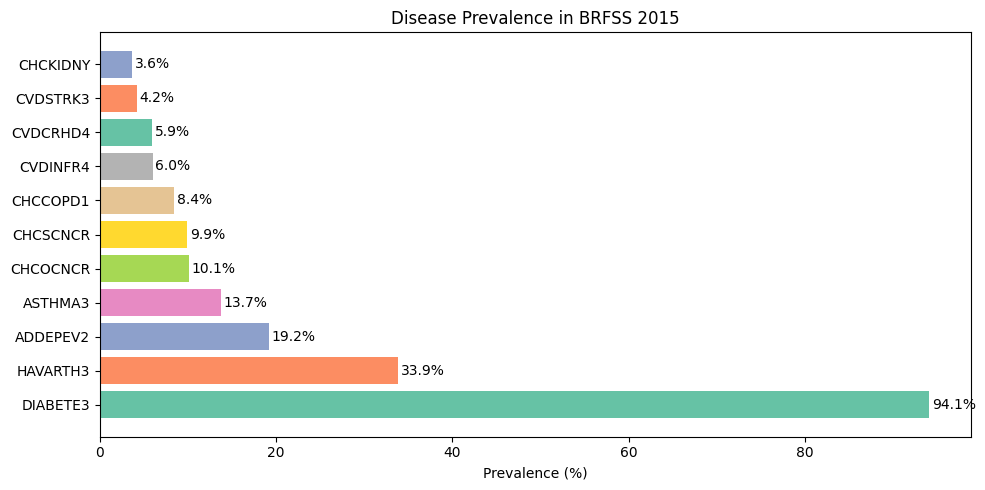

In [13]:
disease_cols = ['CVDINFR4','CVDCRHD4','CVDSTRK3','CHCSCNCR','CHCOCNCR',
                'CHCCOPD1','HAVARTH3','ADDEPEV2','CHCKIDNY','DIABETE3','ASTHMA3']

# Map 1=Yes, 2=No, others=NaN
for col in disease_cols:
    df[col] = df[col].map({1: 1, 2: 0})

prevalence = df[disease_cols].mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(prevalence.index, prevalence.values, color=sns.color_palette("Set2", 11))
ax.set_xlabel("Prevalence (%)")
ax.set_title("Disease Prevalence in BRFSS 2015")
for bar, val in zip(bars, prevalence.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va='center')
plt.tight_layout()
plt.savefig("disease_prevalence.png", dpi=150)

Feature Selection — Key Risk Factor Columns

In [14]:
# Demographic & lifestyle features
feature_cols = [
    '_AGE80',       # Age
    'SEX',          # Sex
    '_BMI5',        # BMI
    'SMOKE100',     # Smoked ≥100 cigarettes
    '_SMOKER3',     # Smoking status
    'DRNKANY5',     # Any alcohol use
    '_TOTINDA',     # Physical activity
    'HLTHPLN1',     # Health plan coverage
    'PHYSHLTH',     # Physical health days bad
    'MENTHLTH',     # Mental health days bad
    'ADSLEEP',     # Sleep hours
    'EDUCA',        # Education
    'INCOME2',      # Income
    '_FRTLT1',      # Fruit consumption
    '_VEGLT1',      # Vegetable consumption
]

Correlation Heatmap

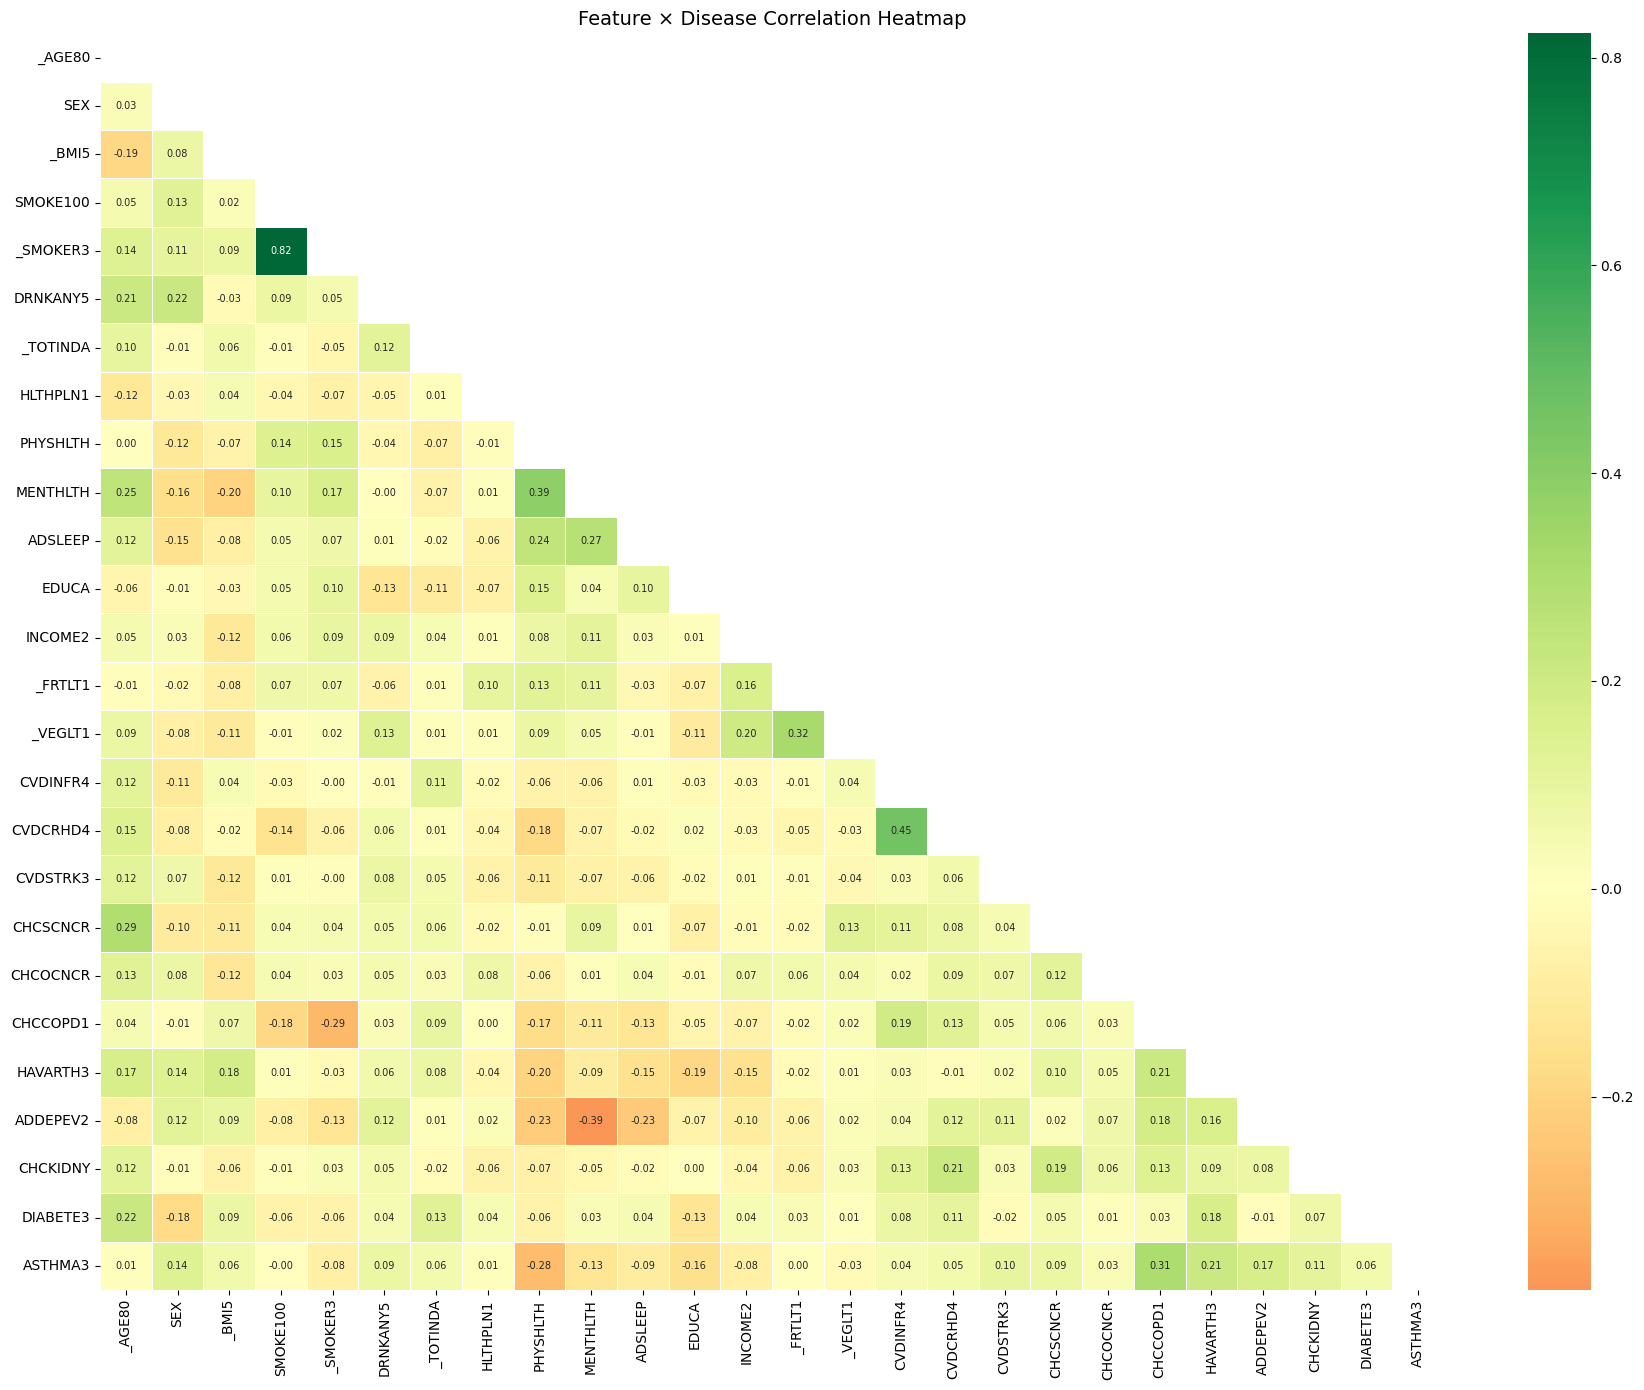

In [15]:
subset = df[feature_cols + disease_cols].dropna()
corr = subset.corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            annot_kws={"size": 7})
plt.title("Feature × Disease Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)

Age Distribution by Disease

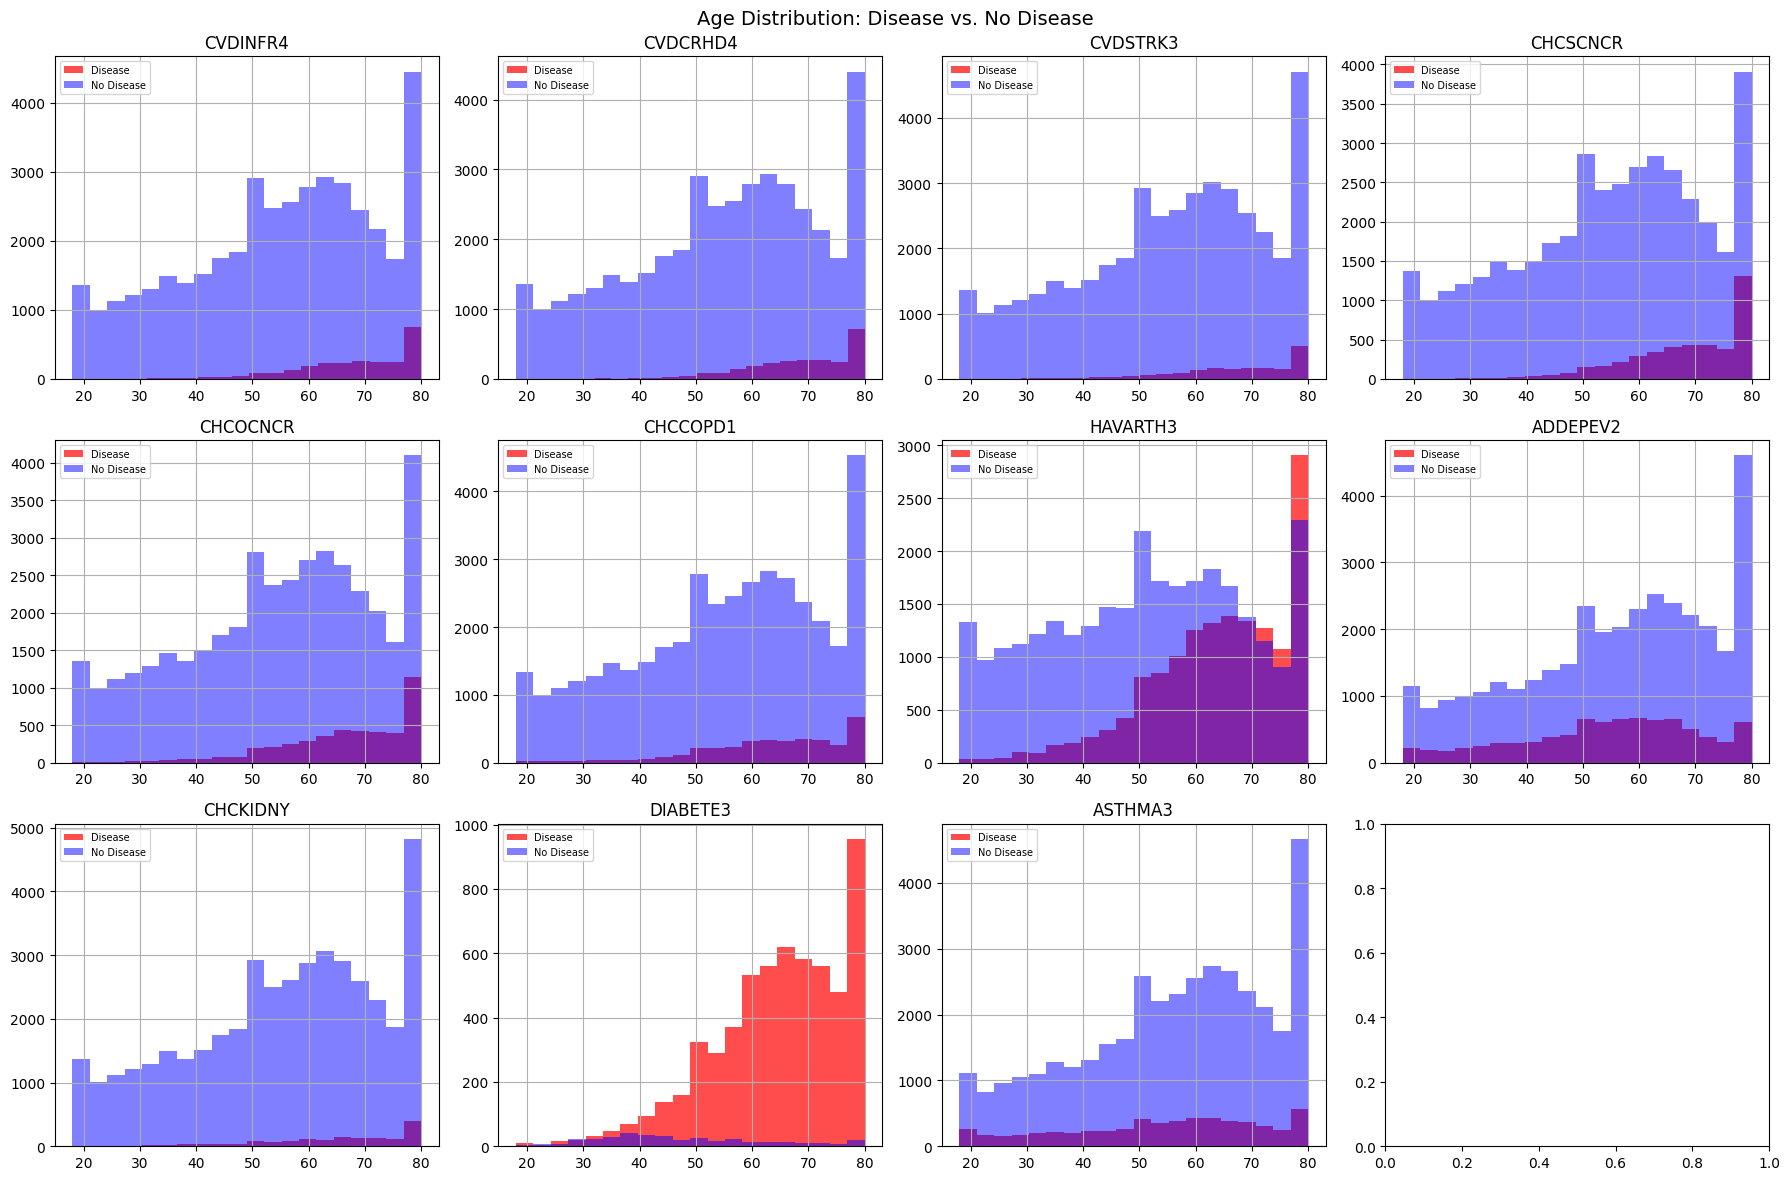

In [16]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, disease in enumerate(disease_cols):
    temp = df[['_AGE80', disease]].dropna()
    temp[temp[disease] == 1]['_AGE80'].hist(ax=axes[i], bins=20, alpha=0.7, color='red', label='Disease')
    temp[temp[disease] == 0]['_AGE80'].hist(ax=axes[i], bins=20, alpha=0.5, color='blue', label='No Disease')
    axes[i].set_title(disease)
    axes[i].legend(fontsize=7)
plt.suptitle("Age Distribution: Disease vs. No Disease", fontsize=14)
plt.tight_layout()
plt.savefig("age_by_disease.png", dpi=150)

Pairplot (Top 5 features × Diabetes)

In [17]:
pair_subset = df[['_AGE80','_BMI5','PHYSHLTH','MENTHLTH','ADSLEEP','DIABETE3']].dropna().sample(3000)
pair_subset['DIABETE3'] = pair_subset['DIABETE3'].astype(int)
sns.pairplot(pair_subset, hue='DIABETE3', palette='Set1',
             plot_kws=dict(alpha=0.4, s=10))
plt.suptitle("Pairplot: Key Features vs Diabetes", y=1.02)
plt.savefig("pairplot_diabetes.png", dpi=150)

ValueError: Cannot take a larger sample than population when 'replace=False'


Class Imbalance Bar Chart

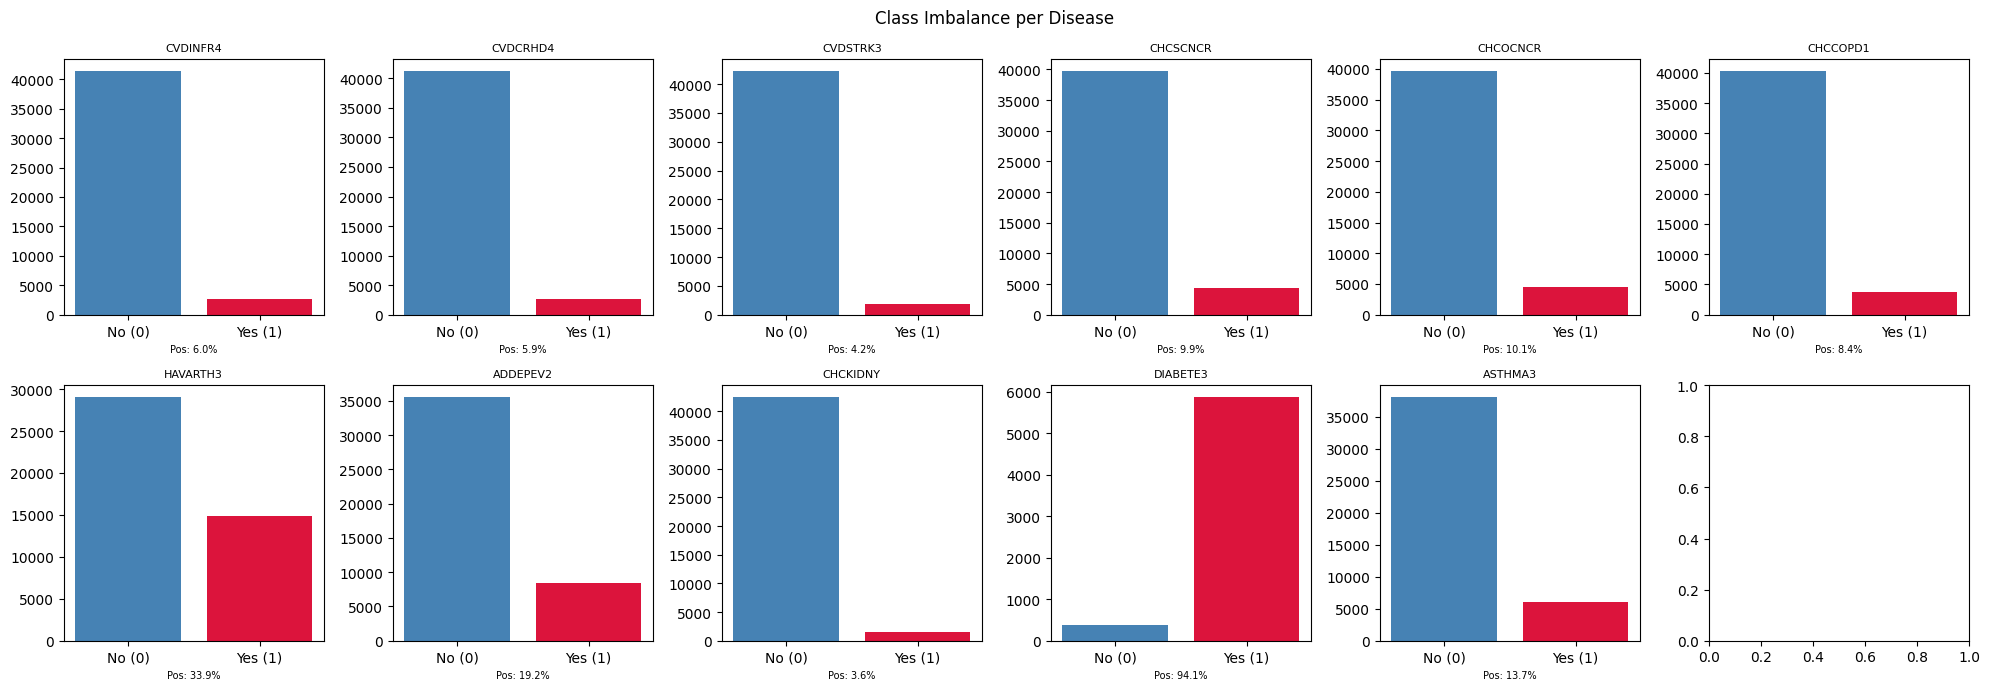

In [18]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
axes = axes.flatten()
for i, disease in enumerate(disease_cols):
    counts = df[disease].value_counts()
    axes[i].bar(['No (0)', 'Yes (1)'], [counts.get(0,0), counts.get(1,0)],
                color=['steelblue','crimson'])
    axes[i].set_title(disease, fontsize=8)
    ratio = counts.get(1,0) / (counts.get(0,1) + counts.get(1,0)) * 100
    axes[i].set_xlabel(f"Pos: {ratio:.1f}%", fontsize=7)
plt.suptitle("Class Imbalance per Disease")
plt.tight_layout()
plt.savefig("class_imbalance.png", dpi=150)

Risk Function, Loss, Bias-Variance

In [19]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Pick one disease to demonstrate pipeline (e.g., Diabetes)
TARGET = 'DIABETE3'

X = df[feature_cols].copy()
y = df[TARGET].copy()

# Drop rows where target is NaN
mask = y.notna()
X, y = X[mask], y[mask]

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE for class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"After SMOTE: {np.bincount(y_train_res.astype(int))}")

After SMOTE: [4690 4690]


Linear Classifiers

In [20]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC, LinearSVC

# LDA (Fisher's Discriminant)
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_res, y_train_res)

# Logistic Regression
lr = LogisticRegression(max_iter=500, C=1.0, random_state=42, verbose=1)
lr.fit(X_train_res, y_train_res)

# SVM with soft margin
svm_soft = SVC(kernel='linear', C=0.5, probability=True, random_state=42, verbose=True)
svm_soft.fit(X_train_res, y_train_res)

# SGD Classifier (stochastic gradient descent)
sgd = SGDClassifier(loss='hinge', max_iter=100, random_state=42, verbose=1)
sgd.fit(X_train_res, y_train_res)

[LibSVM].............*.....*..*.*
optimization finished, #iter = 20383
obj = -1324.319877, rho = -2.465401
nSV = 2666, nBSV = 2648
Total nSV = 2666
.............
*..*......*......*.*
optimization finished, #iter = 26295
obj = -1346.409962, rho = -2.450661
nSV = 2709, nBSV = 2689
Total nSV = 2709
..............
*....*.........*.*
optimization finished, #iter = 26860
obj = -1349.905089, rho = -2.485600
nSV = 2719, nBSV = 2698
Total nSV = 2719
...........
*.......*
optimization finished, #iter = 18658
obj = -1346.716164, rho = -2.429048
nSV = 2710, nBSV = 2692
Total nSV = 2710
...........
*.
*.......*..*
optimization finished, #iter = 20822
obj = -1366.647182, rho = -2.382876
nSV = 2751, nBSV = 2731
Total nSV = 2751
...................*.
*.................*........*.*
optimization finished, #iter = 44222
obj = -1683.910908, rho = 2.510257
nSV = 3385, nBSV = 3367
Total nSV = 3385
-- Epoch 1
Norm: 36.91, NNZs: 15, Bias: 31.644967, T: 9380, Avg. loss: 5.473845, Objective: 5.703751
Total trai

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",100
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",1
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


Kernel & Ensemble Methods

In [21]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import BaggingClassifier, VotingClassifier
from sklearn.model_selection import cross_val_score

# Kernel SVM (RBF)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm_rbf.fit(X_train_res, y_train_res)

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train_res, y_train_res)

# Ensemble (Bagging)
bag = BaggingClassifier(estimator=lr, n_estimators=10, random_state=42)
bag.fit(X_train_res, y_train_res)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.","LogisticRegre...42, verbose=1)"
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",10
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


Neural Networks

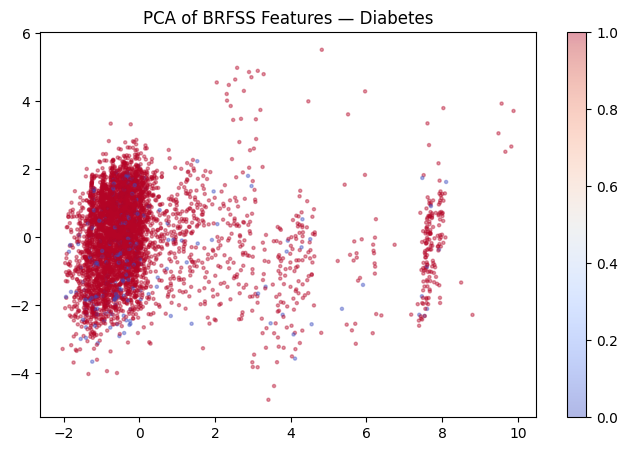

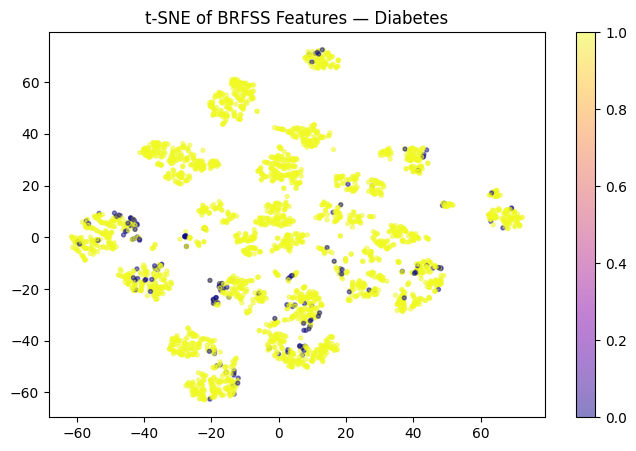

In [22]:
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# MLP with dropout-like regularization (alpha)
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    alpha=0.001,          # L2 regularization (like dropout effect)
    learning_rate='adaptive',
    max_iter=200,
    random_state=42
)
mlp.fit(X_train_res, y_train_res)

# PCA for dimensionality reduction + visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled[:5000])
y_sub = y.values[:5000]
plt.figure(figsize=(8,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_sub, cmap='coolwarm', alpha=0.4, s=5)
plt.colorbar(scatter)
plt.title("PCA of BRFSS Features — Diabetes")
plt.savefig("pca_visualization.png", dpi=150)

# t-SNE visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled[:3000])
y_tsne = y.values[:3000]
plt.figure(figsize=(8,5))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_tsne, cmap='plasma', alpha=0.5, s=8)
plt.colorbar(scatter)
plt.title("t-SNE of BRFSS Features — Diabetes")
plt.savefig("tsne_visualization.png", dpi=150)

Tree Models + Clustering

K-Means Silhouette Score: 0.1350


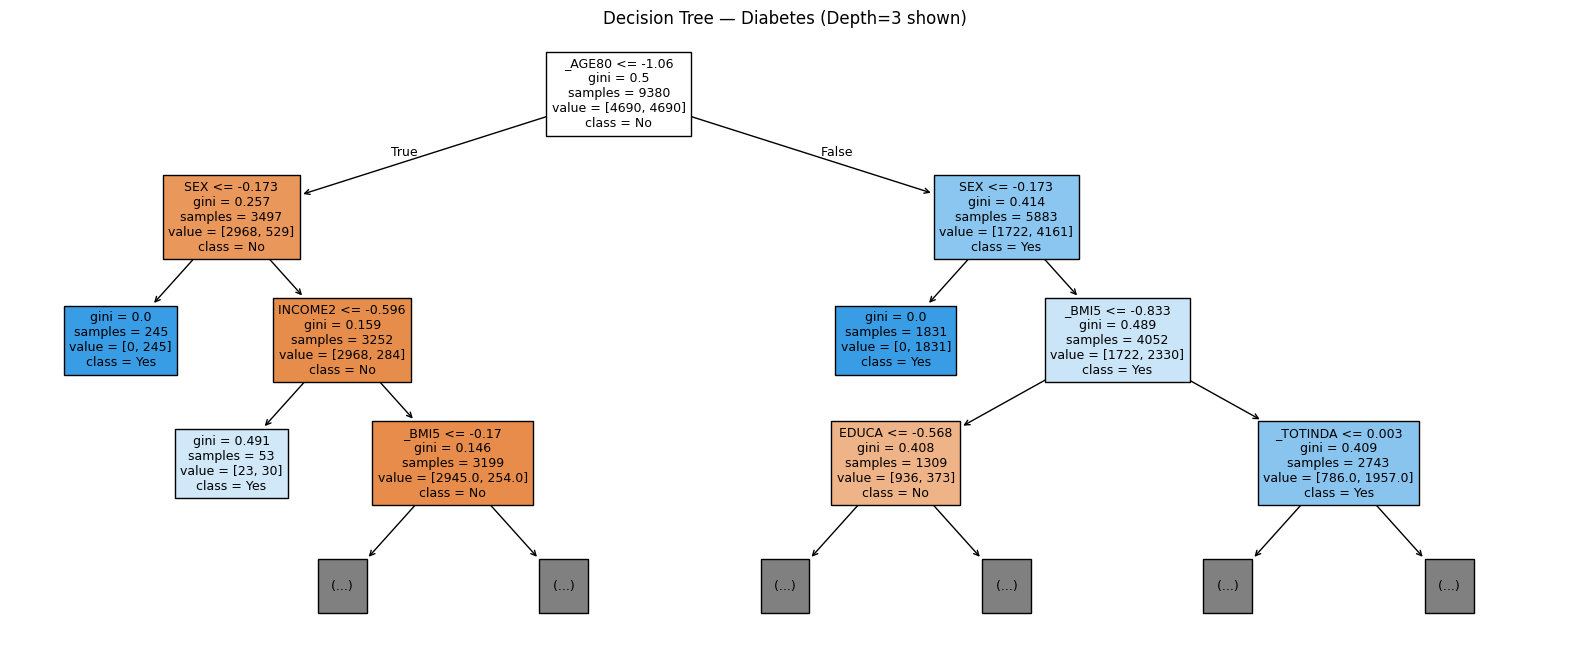

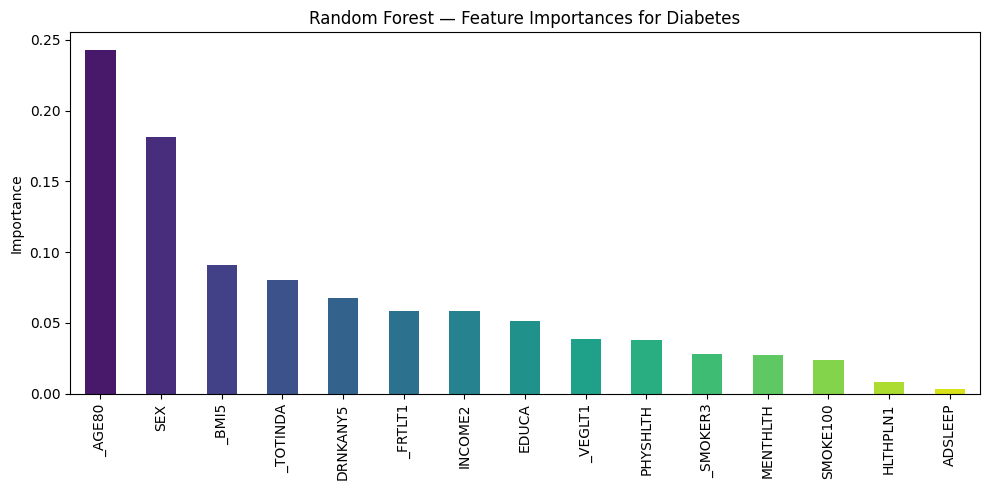

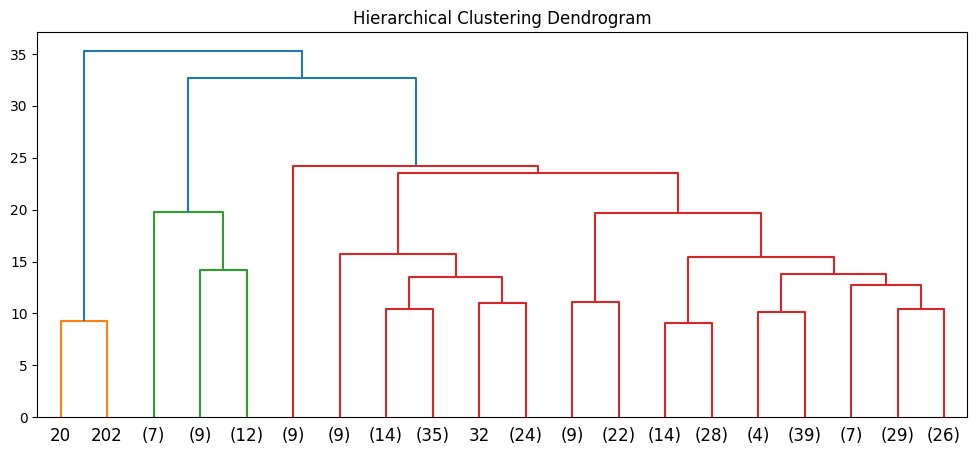

In [23]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# Decision Tree with pruning
dt = DecisionTreeClassifier(criterion='gini', max_depth=6, min_samples_leaf=50, random_state=42)
dt.fit(X_train_res, y_train_res)

# Visualize tree
plt.figure(figsize=(20,8))
plot_tree(dt, feature_names=feature_cols, class_names=['No','Yes'],
          filled=True, max_depth=3, fontsize=9)
plt.title("Decision Tree — Diabetes (Depth=3 shown)")
plt.savefig("decision_tree.png", dpi=150)

# Random Forest with feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color=sns.color_palette("viridis", len(feature_cols)))
plt.title("Random Forest — Feature Importances for Diabetes")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train_res, y_train_res)

# K-Means Clustering (unsupervised)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled[:10000])
sil = silhouette_score(X_scaled[:10000], cluster_labels)
print(f"K-Means Silhouette Score: {sil:.4f}")

# Dendrogram (Hierarchical)
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(X_scaled[:300], method='ward')
plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title("Hierarchical Clustering Dendrogram")
plt.savefig("dendrogram.png", dpi=150)

 Soft Prediction (Probability Output)

In [24]:
models = {
    'Logistic Regression': lr,
    'SVM (RBF)': svm_rbf,
    'Random Forest': rf,
    'MLP': mlp,
    'Gradient Boosting': gb,
    'Naive Bayes': nb
}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # soft prediction
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'pred': y_pred, 'prob': y_prob, 'auc': auc}
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['No Disease','Disease']))
    print(f"ROC-AUC: {auc:.4f}")


--- Logistic Regression ---
              precision    recall  f1-score   support

  No Disease       0.23      0.86      0.36        74
     Disease       0.99      0.82      0.89      1172

    accuracy                           0.82      1246
   macro avg       0.61      0.84      0.63      1246
weighted avg       0.94      0.82      0.86      1246

ROC-AUC: 0.9233

--- SVM (RBF) ---
              precision    recall  f1-score   support

  No Disease       0.29      0.77      0.42        74
     Disease       0.98      0.88      0.93      1172

    accuracy                           0.87      1246
   macro avg       0.64      0.83      0.68      1246
weighted avg       0.94      0.87      0.90      1246

ROC-AUC: 0.9157

--- Random Forest ---
              precision    recall  f1-score   support

  No Disease       0.53      0.49      0.51        74
     Disease       0.97      0.97      0.97      1172

    accuracy                           0.94      1246
   macro avg       0.75  

ROC Curves (All Models)

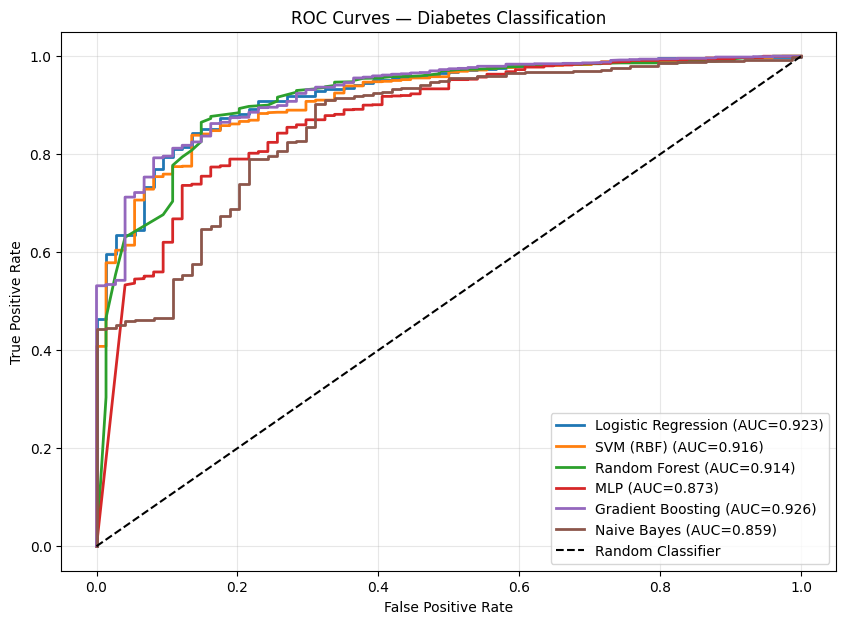

In [25]:
plt.figure(figsize=(10, 7))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", linewidth=2)
plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Diabetes Classification")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig("roc_curves.png", dpi=150)

Confusion Matrices

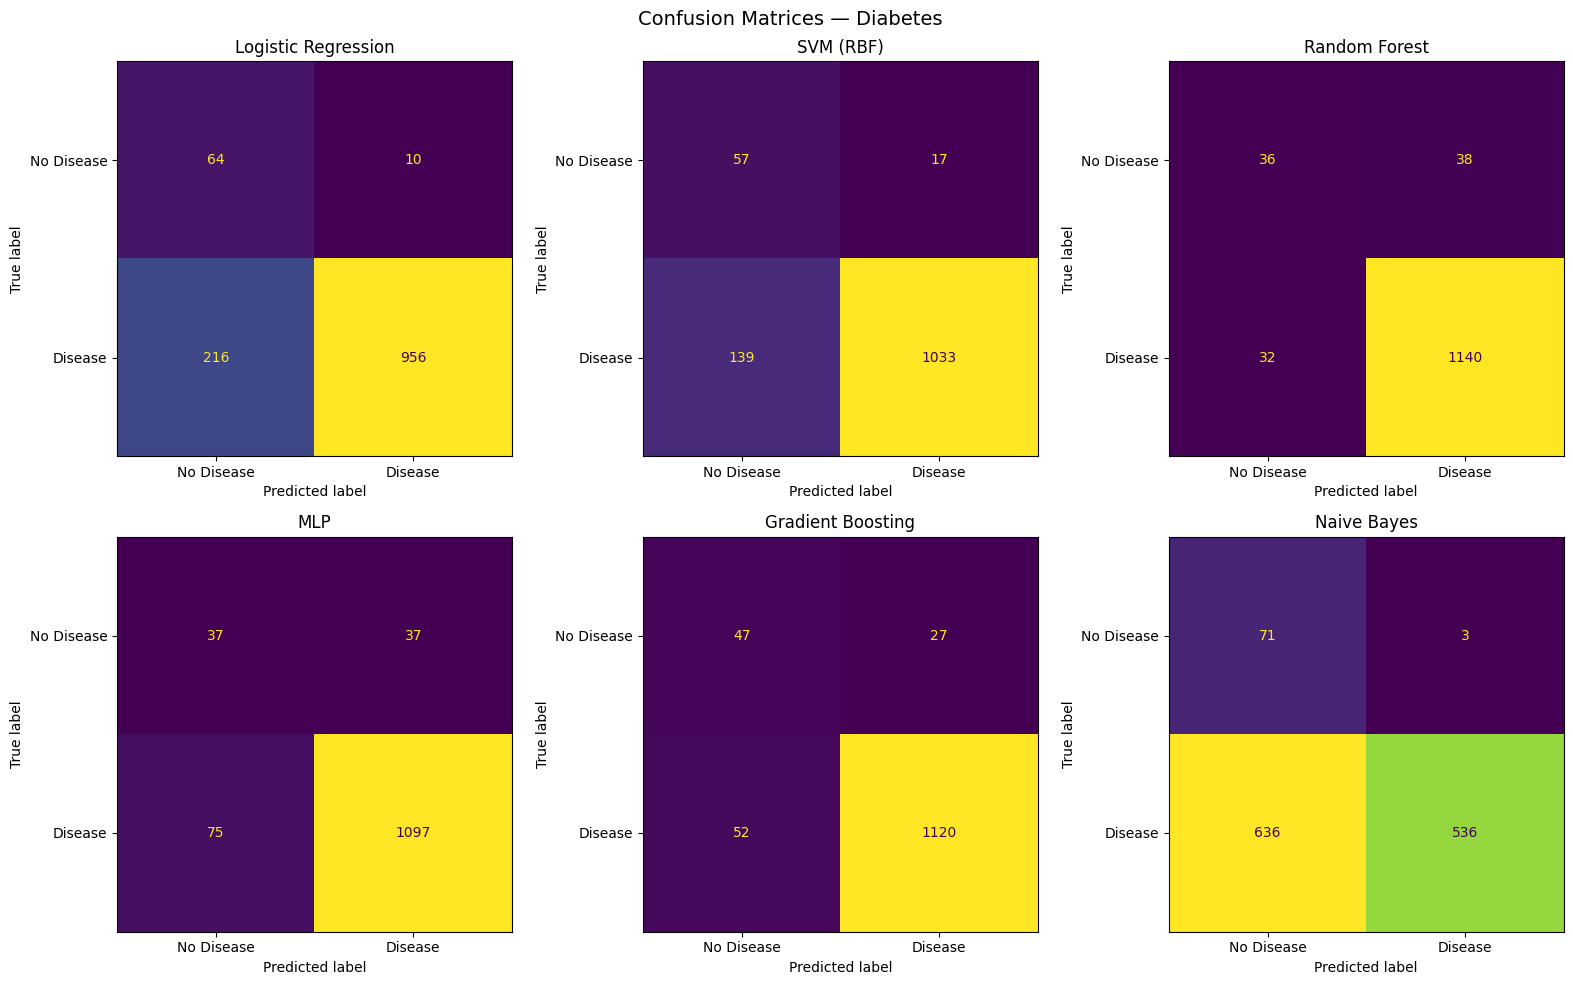

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(name)
plt.suptitle("Confusion Matrices — Diabetes", fontsize=14)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)

 Model Comparison Bar

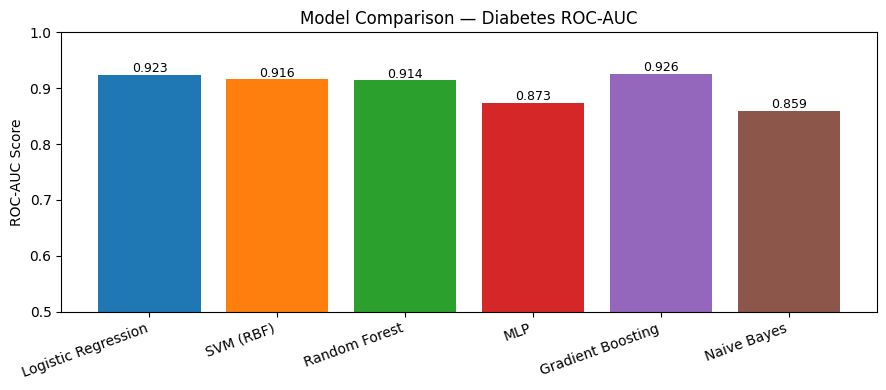

In [27]:
auc_scores = {k: v['auc'] for k, v in results.items()}
plt.figure(figsize=(9, 4))
bars = plt.bar(auc_scores.keys(), auc_scores.values(),
               color=sns.color_palette("tab10", len(auc_scores)))
plt.ylim(0.5, 1.0)
plt.ylabel("ROC-AUC Score")
plt.title("Model Comparison — Diabetes ROC-AUC")
for bar, val in zip(bars, auc_scores.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.3f}", ha='center', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)

Soft Prediction — Sample Output


In [28]:
# Show top-10 test samples with probability scores across diseases
sample_idx = X_test[:10]
print("Soft Predictions (Probability of Disease):\n")
for name, model in models.items():
    probs = model.predict_proba(sample_idx)[:, 1]
    print(f"{name}: {np.round(probs, 3)}")

Soft Predictions (Probability of Disease):

Logistic Regression: [0.071 0.999 0.469 0.698 0.744 0.956 0.999 1.    0.372 0.626]
SVM (RBF): [0.057 0.956 0.718 0.867 0.97  0.996 0.996 0.997 0.343 0.836]
Random Forest: [0.22 0.95 0.94 0.97 0.97 0.97 1.   1.   0.68 0.98]
MLP: [0.001 1.    1.    1.    1.    1.    1.    1.    0.223 1.   ]
Gradient Boosting: [0.168 0.992 0.952 0.953 0.914 0.979 0.983 0.991 0.526 0.95 ]
Naive Bayes: [0.    1.    0.    0.886 0.    0.    1.    1.    0.    0.   ]


 Multi-Disease Pipeline

CVDINFR4: AUC = 0.7566
CVDCRHD4: AUC = 0.7536
CVDSTRK3: AUC = 0.7203
CHCSCNCR: AUC = 0.7235
CHCOCNCR: AUC = 0.6798
CHCCOPD1: AUC = 0.7869
HAVARTH3: AUC = 0.7651
ADDEPEV2: AUC = 0.7722
CHCKIDNY: AUC = 0.7000
DIABETE3: AUC = 0.9138
ASTHMA3: AUC = 0.6144


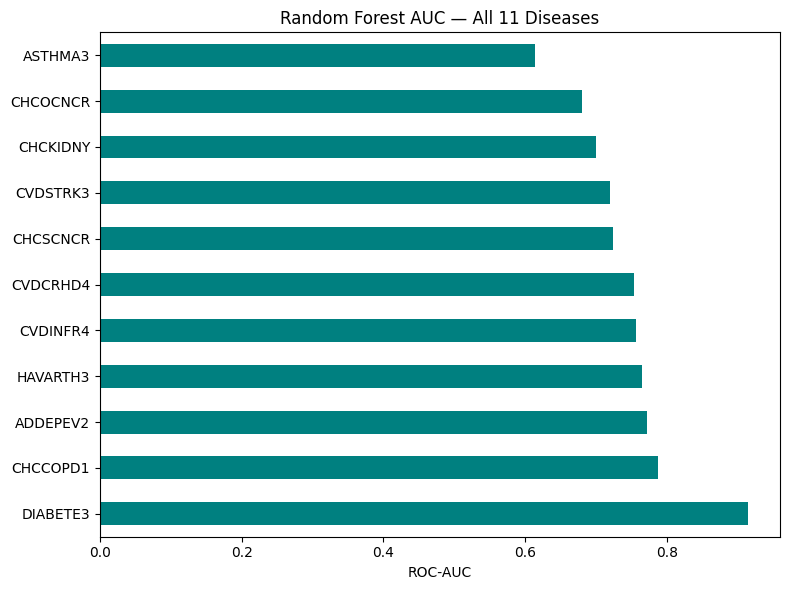

In [29]:
all_results = {}
for TARGET in disease_cols:
    X_t = df[feature_cols].copy()
    y_t = df[TARGET].copy()
    mask = y_t.notna()
    X_t, y_t = X_t[mask], y_t[mask]
    X_imp = imputer.fit_transform(X_t)
    X_sc = scaler.fit_transform(X_imp)
    Xtr, Xte, ytr, yte = train_test_split(X_sc, y_t, test_size=0.2, stratify=y_t, random_state=42)
    Xtr_r, ytr_r = SMOTE(random_state=42).fit_resample(Xtr, ytr)
    rf_t = RandomForestClassifier(100, random_state=42, n_jobs=-1)
    rf_t.fit(Xtr_r, ytr_r)
    auc_t = roc_auc_score(yte, rf_t.predict_proba(Xte)[:,1])
    all_results[TARGET] = round(auc_t, 4)
    print(f"{TARGET}: AUC = {auc_t:.4f}")

# Final summary
pd.Series(all_results).sort_values(ascending=False).plot(kind='barh', figsize=(8,6), color='teal')
plt.xlabel("ROC-AUC")
plt.title("Random Forest AUC — All 11 Diseases")
plt.tight_layout()
plt.savefig("all_diseases_auc.png", dpi=150)